In [5]:
# =========================================================
# Proyecto: Clasificación de Géneros Musicales
# Dataset sintético y desbalanceado + EDA + Modelo
# =========================================================


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

from imblearn.over_sampling import SMOTE


In [6]:
# -------------------------------
# 1. Generación de datos sintéticos
# -------------------------------
np.random.seed(42)

n_samples = 5000
generos = ["Pop", "Rock", "Reggaeton", "Jazz", "Clasica"]
probs = [0.4, 0.3, 0.2, 0.07, 0.03]  # distribución desbalanceada

duracion = np.random.normal(200, 50, n_samples)          
bpm = np.random.normal(120, 30, n_samples)               
energia = np.random.uniform(0, 1, n_samples)
acustica = np.random.uniform(0, 1, n_samples)
popularidad = np.random.randint(0, 101, n_samples)       
instrumentalidad = np.random.beta(2, 5, n_samples)

genero = np.random.choice(generos, size=n_samples, p=probs)

df = pd.DataFrame({
    "duracion": duracion,
    "bpm": bpm,
    "energia": energia,
    "acustica": acustica,
    "popularidad": popularidad,
    "instrumentalidad": instrumentalidad,
    "genero_musical": genero
})

print("Primeras filas del dataset:")
display(df.head())

print("\nDistribución de clases (desbalanceada):")
display(df["genero_musical"].value_counts(normalize=True))



Primeras filas del dataset:


,duracion,bpm,energia,acustica,popularidad,instrumentalidad,genero_musical
0,224.835708,107.287210,0.321255,0.514446,66,0.487393,Pop
1,193.086785,106.397577,0.103019,0.569492,52,0.446088,Pop
2,232.384427,66.130705,0.071808,0.018725,66,0.198034,Rock
3,276.151493,110.097294,0.094276,0.711227,90,0.120492,Reggaeton
4,188.292331,141.984872,0.582869,0.712394,65,0.076932,Rock



Distribución de clases (desbalanceada):


genero_musical
Pop          0.3890
Rock         0.3138
Reggaeton    0.2022
Jazz         0.0676
Clasica      0.0274
Name: proportion, dtype: float64

C:\Users\MB88273\AppData\Local\Temp\ipykernel_24068\2048937762.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="genero_musical", order=df["genero_musical"].value_counts().index, palette="viridis")


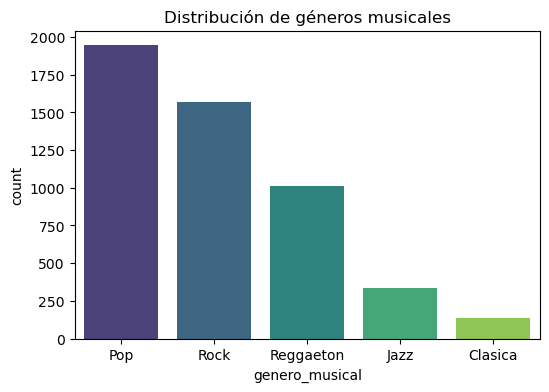

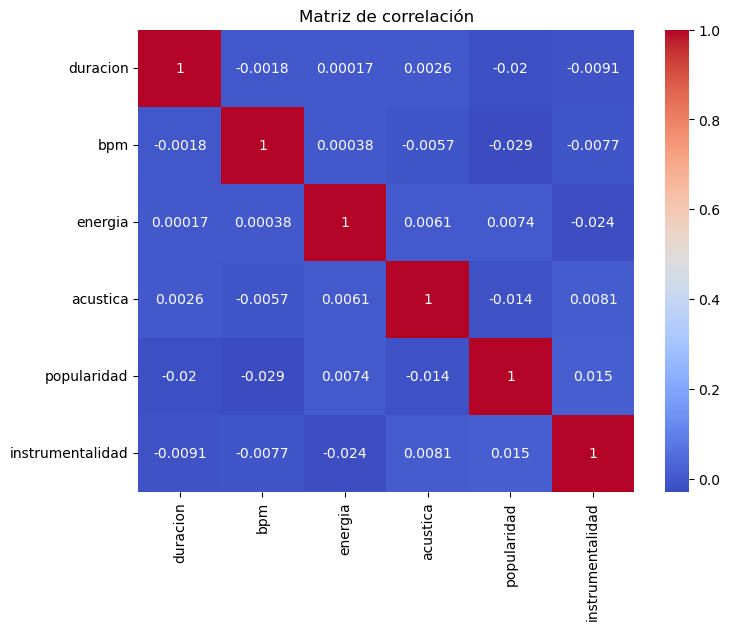

In [7]:
# -------------------------------
# 2. EDA Básico
# -------------------------------

plt.figure(figsize=(6,4))
sns.countplot(data=df, x="genero_musical", order=df["genero_musical"].value_counts().index, palette="viridis")
plt.title("Distribución de géneros musicales")
plt.show()

plt.figure(figsize=(8,6))
sns.heatmap(df.drop(columns=["genero_musical"]).corr(), annot=True, cmap="coolwarm")
plt.title("Matriz de correlación")
plt.show()



Reporte de Clasificación SIN balanceo:
              precision    recall  f1-score   support

     Clasica       0.00      0.00      0.00        27
        Jazz       0.50      0.01      0.03        68
         Pop       0.37      0.62      0.47       389
   Reggaeton       0.20      0.05      0.09       202
        Rock       0.26      0.24      0.25       314

    accuracy                           0.33      1000
   macro avg       0.27      0.19      0.17      1000
weighted avg       0.30      0.33      0.28      1000



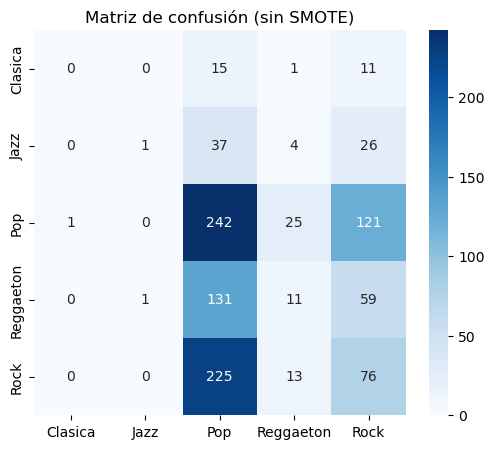

In [8]:
# -------------------------------
# 3. Modelo base (sin balanceo)
# -------------------------------
X = df.drop(columns=["genero_musical"])
y = df["genero_musical"]

le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

model = RandomForestClassifier(random_state=42, n_estimators=100)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("\nReporte de Clasificación SIN balanceo:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Matriz de confusión (sin SMOTE)")
plt.show()




Distribución después de SMOTE:
{'Clasica': 1556, 'Jazz': 1556, 'Pop': 1556, 'Reggaeton': 1556, 'Rock': 1556}

Reporte de Clasificación CON SMOTE:
              precision    recall  f1-score   support

     Clasica       0.06      0.15      0.08        27
        Jazz       0.09      0.15      0.11        68
         Pop       0.39      0.37      0.38       389
   Reggaeton       0.22      0.21      0.22       202
        Rock       0.28      0.23      0.26       314

    accuracy                           0.27      1000
   macro avg       0.21      0.22      0.21      1000
weighted avg       0.29      0.27      0.28      1000



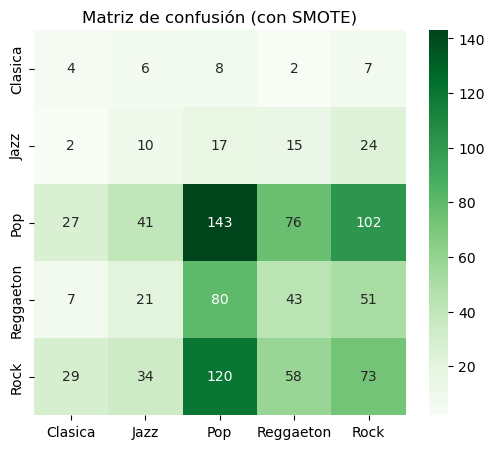

In [9]:
# -------------------------------
# 4. Balanceo con SMOTE
# -------------------------------
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)

print("\nDistribución después de SMOTE:")
unique, counts = np.unique(y_res, return_counts=True)
print(dict(zip(le.inverse_transform(unique), counts)))

# Nuevo modelo entrenado con datos balanceados
model_smote = RandomForestClassifier(random_state=42, n_estimators=100)
model_smote.fit(X_res, y_res)
y_pred_smote = model_smote.predict(X_test)

print("\nReporte de Clasificación CON SMOTE:")
print(classification_report(y_test, y_pred_smote, target_names=le.classes_))

cm_smote = confusion_matrix(y_test, y_pred_smote)
plt.figure(figsize=(6,5))
sns.heatmap(cm_smote, annot=True, fmt="d", cmap="Greens", xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Matriz de confusión (con SMOTE)")
plt.show()